In [2]:
import medmnist
from medmnist import INFO
from torchvision import transforms
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import classification_report , accuracy_score
import matplotlib.pyplot as plt
import numpy as np


In [3]:
dataset_name="breastmnist"
info = INFO[dataset_name]
DataClass = getattr(medmnist, info['python_class'])

#define image transform
transform = transforms.Compose([
    transforms.ToTensor()
])

In [5]:
#load dataset
train_dataset = DataClass(split='train', transform=transform, download=True)
test_dataset = DataClass(split='test', transform=transform, download=True)


100%|██████████| 560k/560k [00:00<00:00, 775kB/s] 


In [9]:
X_train = train_dataset.imgs
Y_train = train_dataset.labels.ravel()
X_test = test_dataset.imgs
Y_test = test_dataset.labels.ravel()


# Flatten the images
X_train_flat = X_train.reshape(len(X_train), -1)
X_test_flat = X_test.reshape(len(X_test), -1)

#NORMALIZE THE DATA
X_train_flat = X_train_flat / 255.0
X_test_flat = X_test_flat / 255.0

# Train SVM classifier with linear kernel
clf= SVC(kernel='linear')
clf.fit(X_train_flat, Y_train)

#make predictions
y_pred = clf.predict(X_test_flat)


# Evaluate the model
print("accuracy_score:", accuracy_score(Y_test, y_pred))
print("classification_report:\n", classification_report(Y_test, y_pred))




accuracy_score: 0.782051282051282
classification_report:
               precision    recall  f1-score   support

           0       0.62      0.50      0.55        42
           1       0.83      0.89      0.86       114

    accuracy                           0.78       156
   macro avg       0.72      0.69      0.70       156
weighted avg       0.77      0.78      0.77       156



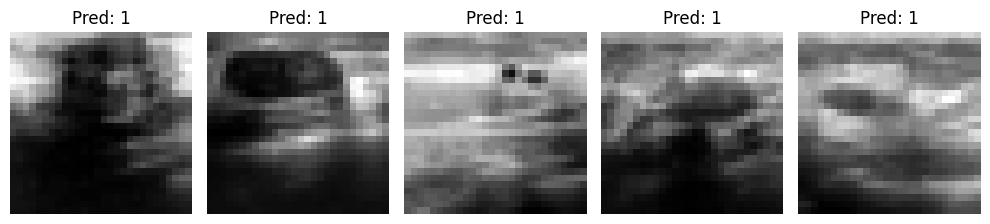

In [ ]:
plt.figure(figsize=(10, 5))
for i in range(5):
    plt.subplot(1, 5, i + 1)
    plt.imshow(X_test[i].squeeze(), cmap='gray')

    plt.title(f'Pred: {y_pred[i]}')
    plt.axis('off')
plt.tight_layout()
plt.show()